In [1]:
from functions import *
import pandas as pd

In [2]:
data = load_data(['stock'], log_returns=True, sort_by_sector=True)

In [3]:
data.head()

,ALV,AMZN,BKNG,COST,CSL,DIS,HD,IDEX,LOW,MCD,...,TXN,V,VZ,BHP,LIN,AMT,PLD,DTE,NEE,SO
date,,,,,,,,,,,,,,,,,,,,,
2019-04-01 10:00:00,0.010458,-0.000391,0.005704,-0.002553,0.006206,0.002423,0.002413,0.016529,0.003795,-0.008312,...,0.005485,-0.000702,-0.006779,-0.000535,-0.000130,-0.009724,-0.010985,-0.010662,-0.012651,-0.007423
2019-04-01 10:30:00,0.000650,0.000192,0.000017,0.002758,0.002007,0.000170,0.001852,0.050610,0.000361,-0.000822,...,0.001205,0.000383,0.002463,0.004982,-0.001139,0.002891,0.002512,0.003664,0.001727,0.004500
2019-04-01 11:00:00,-0.003188,0.001623,0.003041,-0.000288,-0.001043,0.000536,0.002285,-0.028988,0.001802,0.000530,...,0.002498,0.002927,0.000493,-0.000887,0.000677,-0.005168,-0.005594,-0.001006,-0.001100,0.000488
2019-04-01 11:30:00,0.003578,-0.001235,-0.002529,0.000206,-0.001928,0.000223,0.003047,0.000000,-0.010858,-0.000053,...,-0.003424,-0.001144,0.000999,0.000531,0.001240,-0.000752,0.001122,0.004010,0.002094,0.002630
2019-04-01 12:00:00,-0.001690,0.000105,-0.001348,0.000082,-0.000322,0.001115,-0.004135,-0.010753,-0.002916,0.001113,...,0.000556,-0.000573,-0.000476,-0.001064,-0.002876,0.003236,0.003635,0.000444,0.001043,0.001945


In [4]:
corr = correlation(data, 0)

In [5]:
corr_thres = corr_threshold(corr, 0.95)

<Axes: >

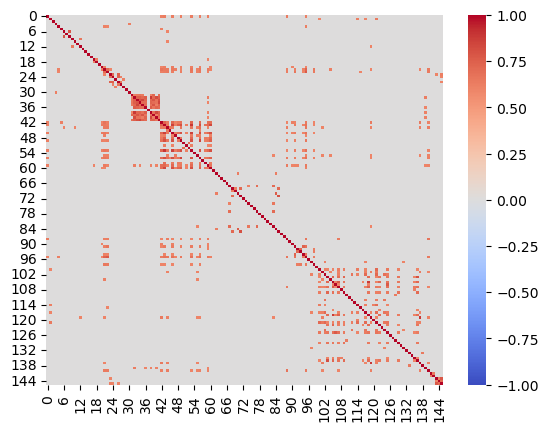

In [6]:
sns.heatmap(corr_thres, cmap='coolwarm', vmin=-1, vmax=1)

## Test var_contagion_masked

In [7]:
matrix_no_mask = var_contagion_masked(data, lag=1, corr_quantile=None, pvalue_threshold=1)
print("Sans masque :")
print(f"  Densite : {contagion_density(matrix_no_mask):.1f}%")

Sans masque :
  Densite : 100.0%


In [8]:
matrix_masked = var_contagion_masked(data, lag=1, corr_quantile=0.95, pvalue_threshold=1)
print(f"Avec masque (corr_quantile=0.95) :")
print(f"  Densite : {contagion_density(matrix_masked):.1f}%")
print()
print("Matrice de contagion masquee :")

Avec masque (corr_quantile=0.95) :
  Densite : 3.7%

Matrice de contagion masquee :


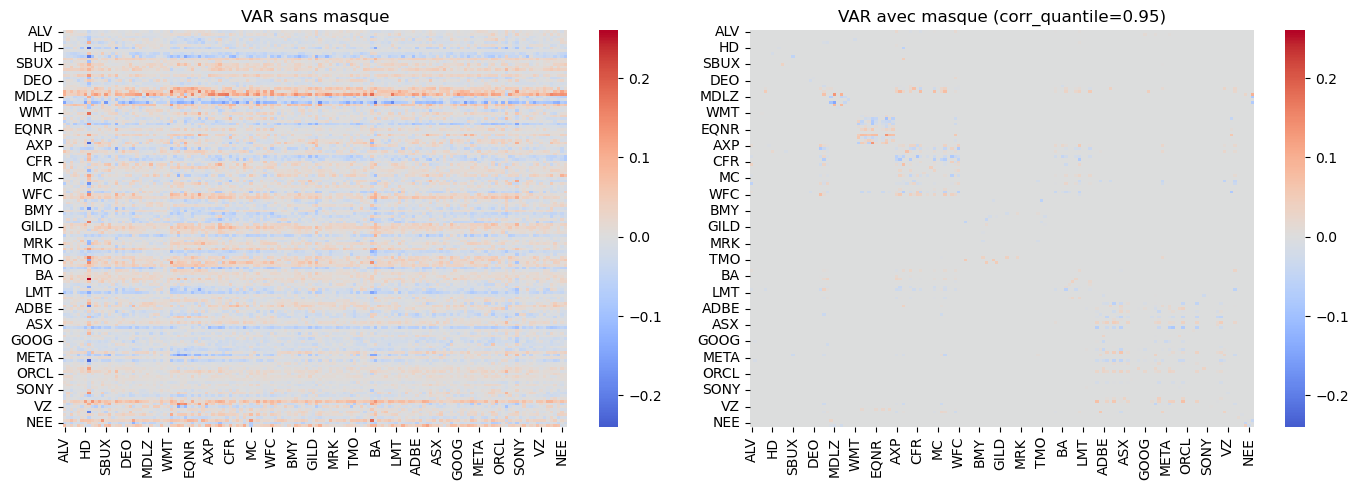

In [9]:
# Comparaison visuelle : sans masque vs avec masque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmin = min(matrix_no_mask.values.min(), matrix_masked.values.min())
vmax = max(matrix_no_mask.values.max(), matrix_masked.values.max())

sns.heatmap(matrix_no_mask, annot=False, cmap='coolwarm', center=0, vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_title("VAR sans masque")

sns.heatmap(matrix_masked, annot=False, cmap='coolwarm', center=0, vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_title("VAR avec masque (corr_quantile=0.95)")

plt.tight_layout()
plt.show()

## R² du modele VAR

In [10]:
# Charger les categories (stock / crypto / etf)
categories = load_categories()

# Matrice de contagion (sans masque)
matrix = var_contagion_masked(data, lag=1, corr_quantile=None, pvalue_threshold=1)

# R² a partir de la matrice
r2 = contagion_r2(data, matrix, lag=1, categories=categories)

print(f"R² total : {r2['total']:.4f}")
print()
print("R² par categorie :")
print(r2["per_category"].to_string())

R² total : 0.0363

R² par categorie :
stock    0.036312


In [11]:
# R² avec masque de correlation (corr_quantile=0.5)
matrix_masked = var_contagion_masked(data, lag=1, corr_quantile=0.5, pvalue_threshold=1)

r2_masked = contagion_r2(data, matrix_masked, lag=1, categories=categories)

print(f"R² total (masque, q=0.5) : {r2_masked['total']:.4f}")
print()
print("R² par categorie (masque) :")
print(r2_masked["per_category"].to_string())

R² total (masque, q=0.5) : 0.0208

R² par categorie (masque) :
stock    0.020791


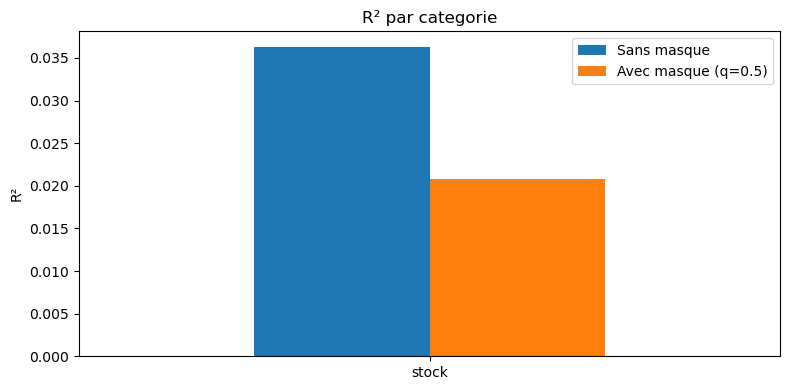

In [12]:
# Comparaison R² : sans masque vs avec masque
comparison = pd.DataFrame({
    "Sans masque": r2["per_category"],
    "Avec masque (q=0.5)": r2_masked["per_category"],
})
comparison.plot.bar(figsize=(8, 4), title="R² par categorie")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Rolling contagion

In [13]:
from importlib import reload
import functions; reload(functions)
from functions import *

for q in [0.9, 0.95, 0.99]:
    print(f"\n{'='*50}")
    print(f"corr_quantile = {q}")
    print(f"{'='*50}")
    res = rolling_contagion(data, corr_quantile=q, asset_type="stock", pvalue_threshold=1, interval_size=10)
    print(f"  k_max = {res['k_max']}, interval_size = {res['interval_size']}")
    print(f"  Intervalles : {len(res['matrices'])}")
    print(f"  Période : {res['intervals'][0][0]} -> {res['intervals'][-1][1]}")
    print(f"  R² global moyen : {res['r2_total']:.4f}")
    print(f"  R² min/max par actif : {res['r2_per_asset'].min():.4f} / {res['r2_per_asset'].max():.4f}")


corr_quantile = 0.9


Rolling contagion: 100%|██████████| 1336/1336 [03:07<00:00,  7.13it/s]


  k_max = 49, interval_size = 10
  Intervalles : 1336
  Période : 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
  R² global moyen : -1.0598
  R² min/max par actif : -34.7910 / 0.0000

corr_quantile = 0.95


Rolling contagion: 100%|██████████| 1336/1336 [02:39<00:00,  8.37it/s]


  k_max = 25, interval_size = 10
  Intervalles : 1336
  Période : 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
  R² global moyen : -1.3809
  R² min/max par actif : -40.3559 / 0.0000

corr_quantile = 0.99


Rolling contagion:  78%|███████▊  | 1042/1336 [01:22<00:23, 12.59it/s]


KeyboardInterrupt: 

### Etude récurrence des coéfficients